In [22]:
import pandas as pd
import numpy as np
import os
import math

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from scipy.stats import pearsonr

import geopandas as gpd
from geopandas import GeoDataFrame
from geopy.distance import geodesic

import cv2
import imageio.v3 as iio
import rasterio

In [21]:
file_path = "/Users/guptsh/Downloads/Soil_Land_Crop/datasets/DLEM_crop_production/Corn/Corn1960.hdr"

if os.path.exists(file_path):
    print("File exists!")
else:
    print("File not found! Check the path.")

File exists!


In [35]:
bin_file_path = "/Users/guptsh/Downloads/Soil_Land_Crop/datasets/DLEM_crop_production/Corn/Corn1960.bin"

try:
    dataset = rasterio.open(bin_file_path)
    print("Dataset loaded successfully!")
    print("Image shape (height, width, bands):", dataset.shape)
    print("Data type:", dataset.dtypes)
    
    # Read the first band
    img_array = dataset.read(1)  # Reads the first band as a NumPy array
    print("Loaded raster data:", img_array.shape)
except Exception as e:
    print("Error loading file:", e)

Dataset loaded successfully!
Image shape (height, width, bands): (292, 693)
Data type: ('float32',)
Loaded raster data: (292, 693)


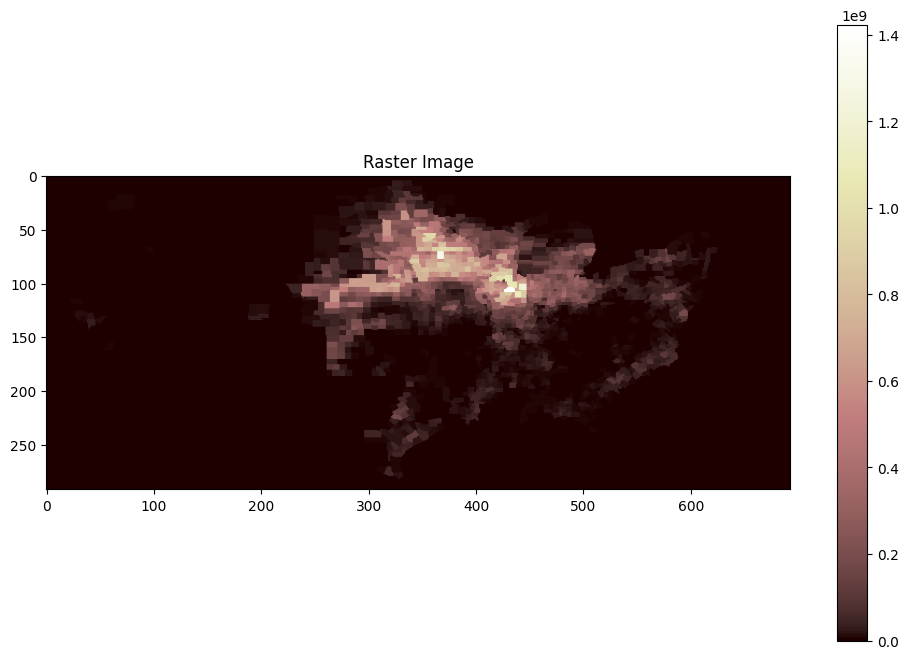

In [45]:
plt.figure(figsize=(12, 8))  
plt.imshow(img_array, cmap="pink")  
plt.colorbar()
plt.title("Raster Image")
plt.show()

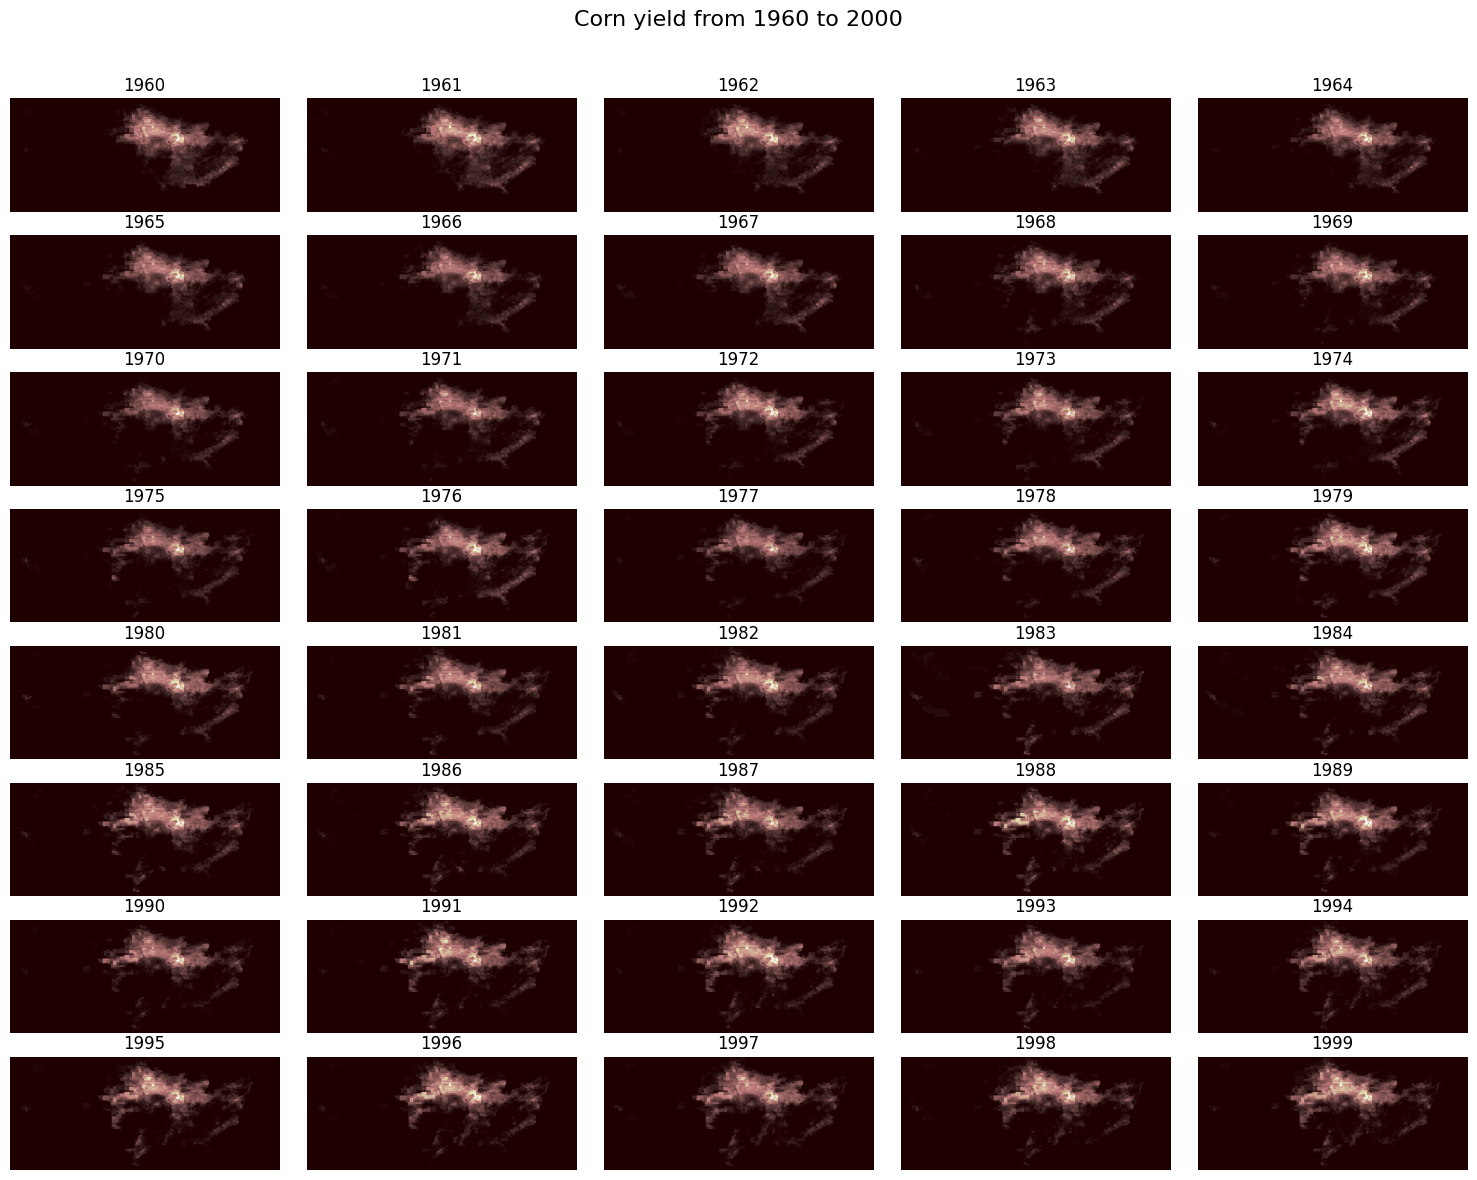

In [43]:
years = list(range(1960, 2000))

fig, axes = plt.subplots(8, 5, figsize = (15, 12))  
fig.suptitle("Corn yield from 1960 to 2000", fontsize=16)

for i, year in enumerate(years):
    bin_file_path = f"/Users/guptsh/Downloads/Soil_Land_Crop/datasets/DLEM_crop_production/Corn/Corn{year}.bin"
    
    try:
        with rasterio.open(bin_file_path) as dataset:
            img_array = dataset.read(1)  

            
            ax = axes[i // 5, i % 5]
            img_plot = ax.imshow(img_array, cmap="pink")  
            ax.set_title(f"{year}")
            ax.axis("off")  

    except Exception as e:
        print(f"Error loading file {bin_file_path}: {e}")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()